In [45]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from config import GROQ_API_KEY
from IPython.display import Image

In [35]:
model = ChatGroq(model='llama-3.3-70b-versatile', api_key=GROQ_API_KEY)

In [36]:
# define state
class BlogState(TypedDict):
    title: str
    outline: str
    blog: str
    score: int

In [37]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']
    
    # Using a more descriptive prompt to get a structured response
    prompt = f"""
    Act as an expert content strategist. Create a comprehensive, SEO-optimized outline for a blog post titled: "{title}".
    
    The outline must include:
    - An Introduction (with a hook and thesis statement)
    - 3 to 5 Main Body sections (H2) with sub-points (H3)
    - A Conclusion with a Call to Action (CTA)
    
    Format the output using clear Markdown headings.
    """
    
    # Call the model
    response = model.invoke(prompt).content
    
    # Update the state with the generated outline
    state['outline'] = response
    
    return state


In [38]:
def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    
    # Prompting for flow and professional formatting
    prompt = f"""
    Write a high-quality, engaging blog post based on the title and outline below.
    
    TITLE: {title}
    OUTLINE: 
    {outline}
    
    INSTRUCTIONS:
    - Use a professional yet conversational tone.
    - Use Markdown for bolding, bullet points, and headers (H2, H3).
    - Ensure smooth transitions between the sections defined in the outline.
    - Do not include meta-commentary like "Sure, here is your blog." Start directly with the content.
    """
    
    # Generate the blog content
    response = model.invoke(prompt).content
    
    # Update state
    state['blog'] = response
    
    return state


In [48]:
def blog_score(state: BlogState) -> BlogState:
    outline = state['outline']
    blog = state['blog']
    
    # Using a structured prompt for better accuracy
    prompt = f"""
    You are a professional content editor. Evaluate the blog post below against the provided outline.
    
    OUTLINE:
    {outline}
    
    BLOG CONTENT:
    {blog}
    
    SCORING CRITERIA:
    1. Adherence: Does the blog cover all points in the outline?
    2. Quality: Is the writing engaging and clear?
    3. Formatting: Are H2/H3 tags used correctly as per the outline?
    
    Provide a single integer score from 1 to 100 where 100 is perfect. 
    Respond ONLY with the integer.
    """
    
    # Invoke the model and clean the output to ensure it's an integer
    response = model.invoke(prompt).content
    try:
        # Extract only the digits in case the model adds extra text
        blog_score = int(''.join(filter(str.isdigit, response)))
    except ValueError:
        blog_score = 0  # Fallback error score
    
    state['score'] = blog_score
    return state


In [51]:
# define graph
graph = StateGraph(BlogState)

# add node to the graph
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('blog_score', blog_score)

# add edges to the node
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'blog_score')
graph.add_edge('blog_score', END)

# compile the graph
workflow = graph.compile()

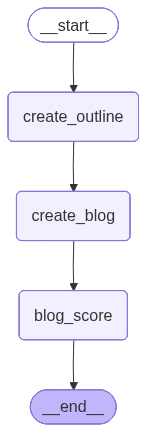

In [52]:
Image(workflow.get_graph().draw_mermaid_png())

In [41]:
initial_state = {'title': 'Rise of Agentic AI'}

# execute the workflow
final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of Agentic AI', 'outline': '# Introduction\nThe emergence of Artificial Intelligence (AI) has been a significant talking point in recent years, with many experts predicting a future where machines surpass human intelligence. However, a new subset of AI, known as Agentic AI, is gaining traction and promises to revolutionize the way we interact with technology. As we delve into the world of Agentic AI, one question remains: what does the rise of Agentic AI mean for humanity, and how will it shape our future? This blog post will explore the concept of Agentic AI, its applications, and the potential implications of its rise, with a focus on how it can be harnessed to augment human capabilities.\n\n# Main Body\n## What is Agentic AI\n### Definition and Characteristics\nAgentic AI refers to a type of AI that is capable of autonomous decision-making, self-modification, and adaptation. This subset of AI is characterized by its ability to learn from its environment, make decisio

In [42]:
print(final_state['outline'])

# Introduction
The emergence of Artificial Intelligence (AI) has been a significant talking point in recent years, with many experts predicting a future where machines surpass human intelligence. However, a new subset of AI, known as Agentic AI, is gaining traction and promises to revolutionize the way we interact with technology. As we delve into the world of Agentic AI, one question remains: what does the rise of Agentic AI mean for humanity, and how will it shape our future? This blog post will explore the concept of Agentic AI, its applications, and the potential implications of its rise, with a focus on how it can be harnessed to augment human capabilities.

# Main Body
## What is Agentic AI
### Definition and Characteristics
Agentic AI refers to a type of AI that is capable of autonomous decision-making, self-modification, and adaptation. This subset of AI is characterized by its ability to learn from its environment, make decisions based on that learning, and modify its own arch

In [43]:
print(final_state['blog'])

## Introduction
The emergence of Artificial Intelligence (AI) has been a significant talking point in recent years, with many experts predicting a future where machines surpass human intelligence. However, a new subset of AI, known as Agentic AI, is gaining traction and promises to revolutionize the way we interact with technology. As we delve into the world of Agentic AI, one question remains: what does the rise of Agentic AI mean for humanity, and how will it shape our future? This blog post will explore the concept of Agentic AI, its applications, and the potential implications of its rise, with a focus on how it can be harnessed to augment human capabilities.

## Main Body
### What is Agentic AI
#### Definition and Characteristics
Agentic AI refers to a type of AI that is capable of autonomous decision-making, self-modification, and adaptation. This subset of AI is characterized by its ability to learn from its environment, make decisions based on that learning, and modify its own 

In [44]:
print(final_state['score'])

98
